In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from .utils import load_config
from pathlib import Path

# Load data
config = load_config('../configs/config.yaml')

train_csv_path = Path('../') / config['data']['train_csv']
df = pd.read_csv(train_csv_path)

# 1. Data Cleaning
# Check for missing values

missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

ImportError: attempted relative import with no known parent package

In [3]:
# 2. Identifica le colonne dei sensori (quelle che iniziano con "Sensed_")
sensor_cols = [col for col in df.columns if col.startswith('Sensed_')]

# 3. Calcola il minimo, il massimo e l'intervallo (range)
# Usiamo il metodo .agg() per ottenere min e max contemporaneamente
sensor_ranges = df[sensor_cols].agg(['min', 'max']).transpose()

# 4. Mostra i risultati
print("Range di ogni sensore:")
print(sensor_ranges)

Range di ogni sensore:
                            min            max
Sensed_Altitude     -489.554524   35019.554225
Sensed_Mach            0.000849       0.746895
Sensed_Pamb            3.443702      14.952901
Sensed_Pt2             4.553797      15.509660
Sensed_TAT           421.761542     563.312926
Sensed_WFuel           0.000000     123.198618
Sensed_VAFN          502.877626    8161.681287
Sensed_VBV             0.000000       4.776258
Sensed_Fan_Speed       0.000000    1984.597625
Sensed_Core_Speed      0.000000  235762.778358
Sensed_T25         -2379.012207  895556.308785
Sensed_T3            588.017684   27943.085337
Sensed_Ps3             7.226304     525.844996
Sensed_T45             0.538878   27811.130622
Sensed_P25        -19003.917865      45.877380
Sensed_T5              0.537815   27675.035363


In [4]:
# Conta i valori esattamente uguali a 0 per ogni colonna
zeros_count = (df == 0).sum()

print("Conteggio dei valori zero per ogni colonna:")
print(zeros_count)

Conteggio dei valori zero per ogni colonna:
ESN                       0
Cycles                   28
Snapshot                  0
Cumulative_WWs         3018
Cumulative_HPC_SVs    25772
Cumulative_HPT_SVs    12476
Sensed_Altitude           0
Sensed_Mach               0
Sensed_Pamb               0
Sensed_Pt2                0
Sensed_TAT                0
Sensed_WFuel            188
Sensed_VAFN               0
Sensed_VBV            48451
Sensed_Fan_Speed        670
Sensed_Core_Speed        23
Sensed_T25                0
Sensed_T3                 0
Sensed_Ps3                0
Sensed_T45                0
Sensed_P25                0
Sensed_T5                 0
Cycles_to_WW            618
Cycles_to_HPC_SV         91
Cycles_to_HPT_SV        192
dtype: int64


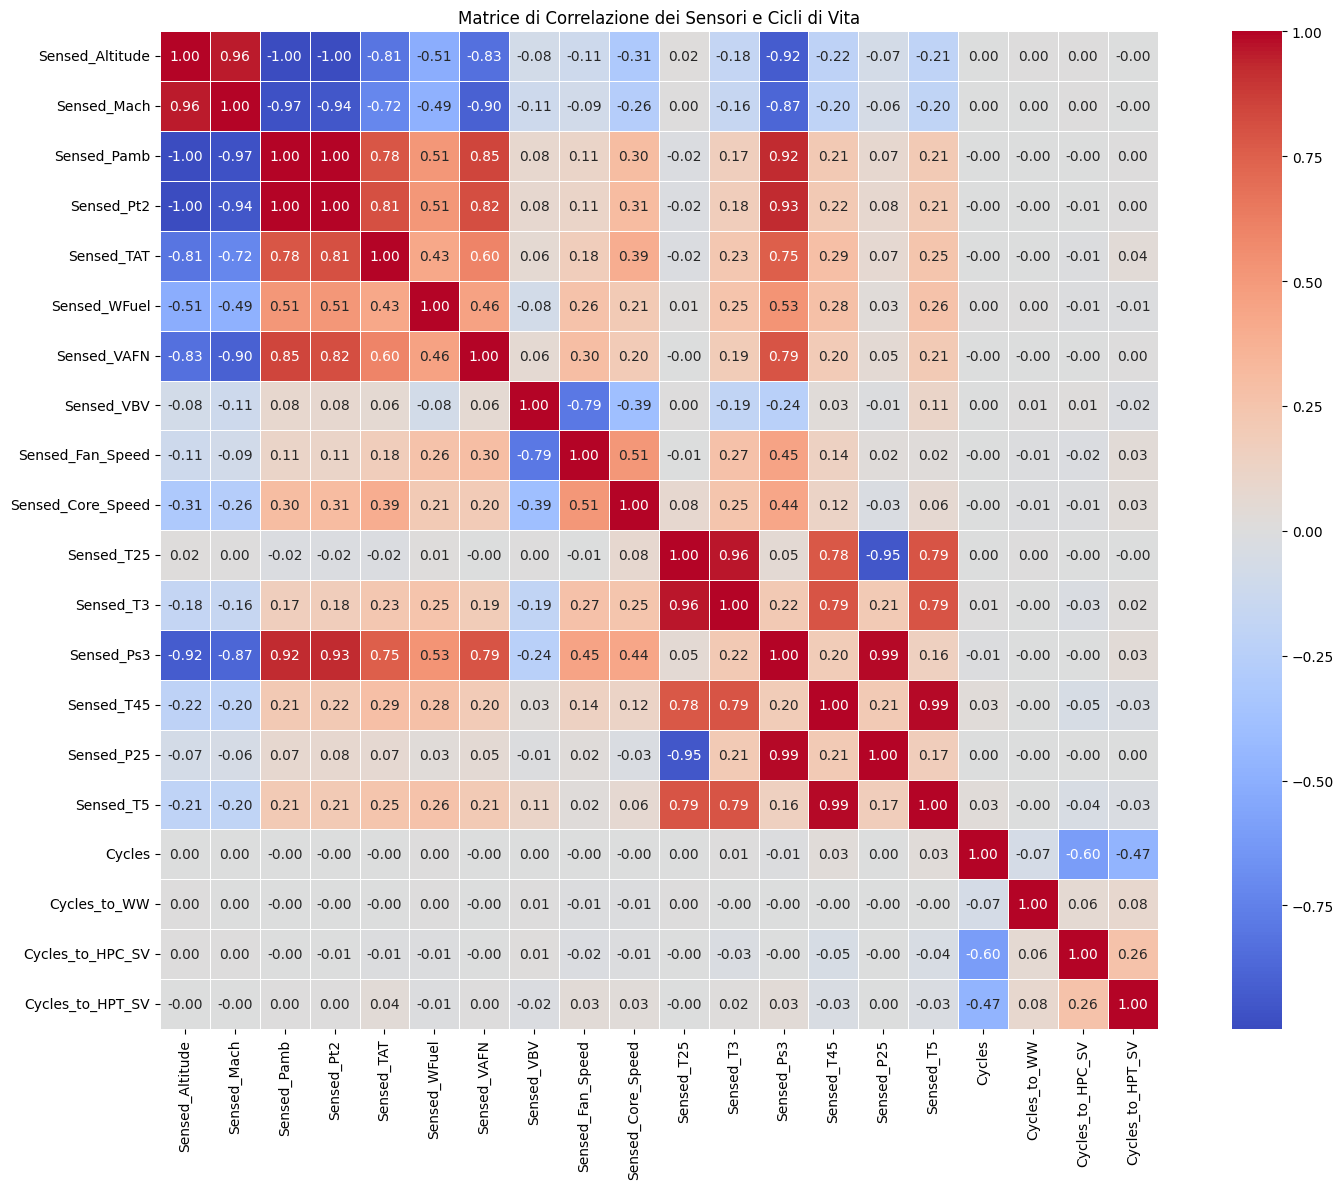

In [6]:
# 2. Seleziona le colonne di interesse (Sensori e Cicli)
cols_to_corr = [col for col in df.columns if col.startswith('Sensed_')] + \
               ['Cycles', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']

# 3. Calcola la matrice di correlazione
corr_matrix = df[cols_to_corr].corr()

# 4. Crea il grafico (Heatmap)
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)

plt.title('Matrice di Correlazione dei Sensori e Cicli di Vita')
plt.tight_layout()

                   Cycles_to_WW  Cycles_to_HPC_SV  Cycles_to_HPT_SV
Sensed_Fan_Speed          -0.01             -0.02              0.03
Sensed_VBV                 0.01              0.01             -0.02
Sensed_Core_Speed         -0.01             -0.01              0.03
Sensed_T45                -0.00             -0.05             -0.03
Sensed_VAFN               -0.00             -0.00              0.00
Sensed_TAT                -0.00             -0.01              0.04
Sensed_WFuel               0.00             -0.01             -0.01
Sensed_T3                 -0.00             -0.03              0.02
Sensed_T5                 -0.00             -0.04             -0.03
Sensed_T25                 0.00             -0.00             -0.00
Sensed_Altitude            0.00              0.00             -0.00
Sensed_Pt2                -0.00             -0.01              0.00
Sensed_Pamb               -0.00             -0.00              0.00
Sensed_P25                -0.00             -0.0

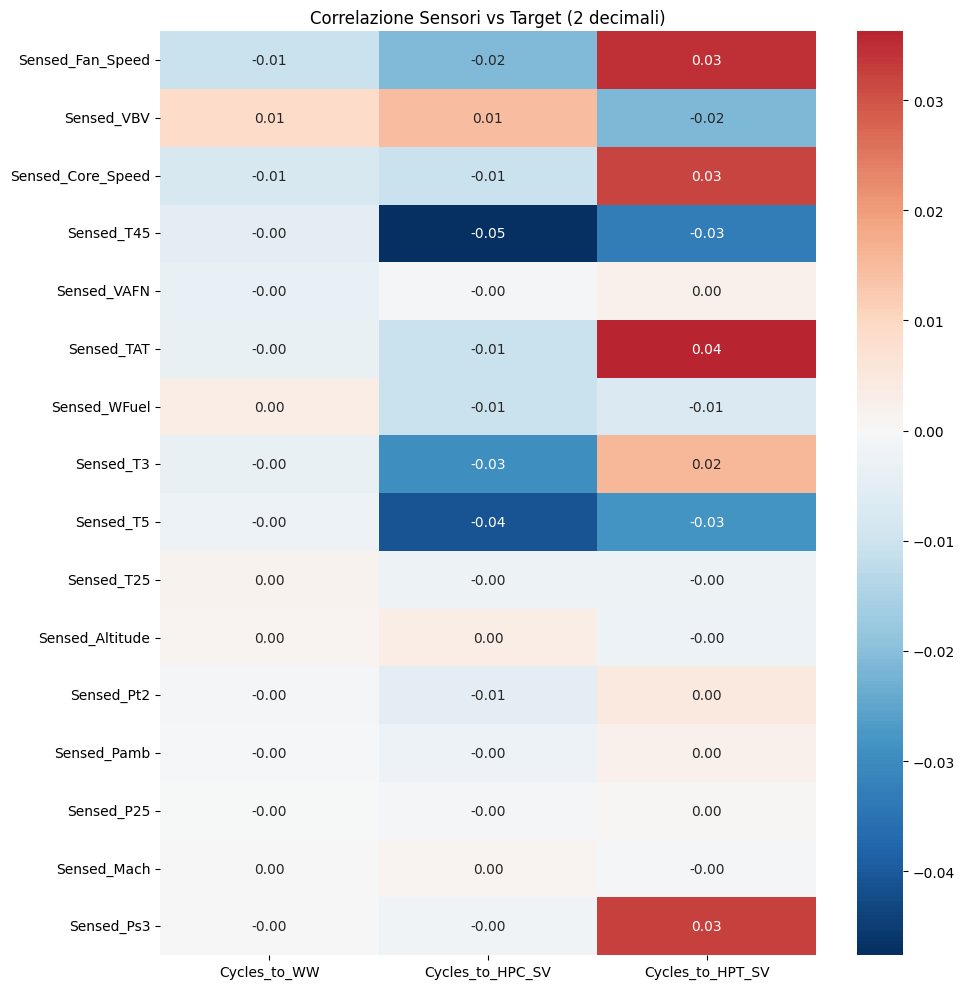

In [8]:
# Definiamo le colonne dei sensori e i target
sensor_cols = [col for col in df.columns if col.startswith('Sensed_')]
target_cols = ['Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']

# Calcolo correlazione incrociata (Sensori vs Target)
sensor_target_corr = df[sensor_cols + target_cols].corr().loc[sensor_cols, target_cols]

# Ordiniamo per valore assoluto della correlazione con il primo target
sensor_target_corr_sorted = sensor_target_corr.reindex(
    sensor_target_corr['Cycles_to_WW'].abs().sort_values(ascending=False).index
)

# Visualizzazione Heatmap con 2 cifre decimali
plt.figure(figsize=(10, 10))
sns.heatmap(sensor_target_corr_sorted, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Correlazione Sensori vs Target (2 decimali)')
plt.tight_layout()

# Formattazione per la stampa testuale
print(sensor_target_corr_sorted.round(2))